# Notebook 01: Raw Data Exploration
**Project:** Tracking Proposed Data Centers Near Superfund Sites


## Purpose
This notebook explores the raw data from two sources before any cleaning
or preprocessing:
- FracTracker data center dataset
- EPA Superfund site dataset

The goal is to understand the quality and limitations of these datasets in order to decide what preprocessing steps need to be addressed before analysis.  The analysis in this notebook contributed to the decisions made in: `src/preprocess.py`.

In [33]:
import os
import pandas as pd
import geopandas as gpd
import numpy as  np
import matplotlib.pyplot as plt
import seaborn as sns


from src.tufte_style import define_plot_style
from src.tufte_style import COLORS, STATUS_PALETTE, REGION_PALETTE, EO_PALETTE

In [34]:
## Setup
# Standard imports and color configuration:
# `COLORS`, `STATUS_PALETTE`,`REGION_PALETTE`, and `EO_PALETTE` are defined here and used consistently throughout all project notebooks. `plt.rcParams` sets global figure styling.
plt.style.use('seaborn-v0_8-whitegrid')
define_plot_style()

## Data Sources

### Data Centers (FracTracker)
FracTracker is a crowdsourced but moderated platform that collects data about potential AI data centers before they are formalized in their communites. The data center dataset includes proposed,
operating, and inactive facilities across the United States.

**Key limitation:** As a crowdsourced dataset, coverage may be uneven across
regions and time periods. Data entry dates do not necessarily reflect
real-world proposal dates.

### EPA Superfund (National Priorities List)
The EPA Superfund dataset is a GIS dataset that contains polygon geometries for the boundaries of EPA Superfund sites. Each site may have multiple feature rows representing
different boundary types (comprehensive site area, extent of contamination, etc.)


**Key limitation:** The dataset represents site boundaries as understood at the
time of last update. Cleanup status and contamination severity are not captured
in this file.

In [35]:
DATA_CENTERS_DIR = "../data/raw/data_centers"
SUPERFUND_DIR = "../data/raw/epa_superfund"
DATA_CENTERS_FILE = "data_centers_raw.csv"
SUPERFUND_FILE = "superfund_raw.csv"
dc_df = pd.read_csv(os.path.join(DATA_CENTERS_DIR, DATA_CENTERS_FILE))
dc_gdf = gpd.read_file(os.path.join(DATA_CENTERS_DIR, DATA_CENTERS_FILE))
sf_df = pd.read_csv(os.path.join(SUPERFUND_DIR, SUPERFUND_FILE))
sf_gdf = gpd.read_file(os.path.join(SUPERFUND_DIR, SUPERFUND_FILE))
plt.style.use('seaborn-v0_8-whitegrid')
define_plot_style()


In [36]:
sf_gdf['GIS_AREA'] = pd.to_numeric(sf_gdf['GIS_AREA'], errors='coerce')


In [37]:
dc_gdf.head()

,facility_name,address,city,state,zip,county,lat,long,status,location_confidence,...,info_source_1,info_source_2,info_source_3,info_source_4,info_source_5,info_source_6,info_source_7,info_source_8,date_created,date_updated
0,Project Marvel,Rock Mountain Lake Rd,Bessemer,AL,35022.0,Jefferson,33.342,-87.0341,Proposed,High,...,https://www.datacenterdynamics.com/en/news/700...,https://www.youtube.com/watch?v=ICSrvQ7meow&ab...,https://www.al.com/news/2025/06/14-billion-pro...,https://www.wbrc.com/2025/09/14/bessemer-resid...,https://www.wbrc.com/2025/11/19/bessemer-city-...,https://www.datacenterdynamics.com/en/news/ala...,https://abc3340.com/news/abc-3340-news-iteam/b...,,09/16/2025,03/13/2026
1,DC Blox,433 6th St S,Birmingham,AL,35233.0,Jefferson,33.50051,-86.821,Operating,High,...,,,,,,,,,08/25/2025,08/25/2025
2,Google Data Center,48809 Alabama 277,Bridgeport,AL,35740.0,Jackson,34.92019,-85.7446,Operating,High,...,https://www.madeinalabama.com/2018/04/google-k...,https://claycorp.com/work/mission-critical,,,,,,,07/15/2025,02/18/2026
3,Western Hospitality Partners Data Center,Childersburg Industrial Park,Childersburg,AL,35044.0,Talladega,33.340885,-86.336205,Proposed,Medium,...,https://www.datacenterdynamics.com/en/news/pla...,https://www.childersburg.org/childersburg-indu...,,,,,,,01/26/2026,01/26/2026
4,DC Blox,333 Diamond Dr NW,Huntsville,AL,35806.0,Madison,34.71003,-86.693,Operating,High,...,,,,,,,,,08/25/2025,08/25/2025


In [38]:
sf_gdf.head()

,OBJECTID,REGION_CODE,EPA_PROGRAM,EPA_ID,SITE_NAME,SITE_FEATURE_CLASS,SITE_FEATURE_TYPE,SITE_FEATURE_NAME,SITE_FEATURE_DESCRIPTION,NPL_STATUS_CODE,...,URL_ALIAS_TXT,FEATURE_INFO_URL,FEATURE_INFO_URL_DESC,GIS_AREA,GIS_AREA_UNITS,PROJECTION,SF_GEOSPATIAL_DATA_DISCLAIMER,Shape__Area,Shape__Length,geometry_wkt
0,1,1,Superfund Remedial,CTD001452093,DURHAM MEADOWS,5,Extent of Contamination,Approximate Durham Meadows Site Boundary,The Site is located in the town of Durham in M...,F,...,https://www.epa.gov/superfund/durham,https://semspub.epa.gov/src/document/01/100018870,,82.422604,Acres,Albers Equal Area,The Agency is providing this geospatial inform...,3.595713747017726e-05,0.029649650116336173,"POLYGON ((-72.6805105970863 41.4818652958468, ..."
1,2,1,Superfund Remedial,VTD000860239,OLD SPRINGFIELD LANDFILL,5,OU Boundary Aggregation,Approximate Old Springfield Landfill Site Boun...,The 10-acre Site is located approximately 1 mi...,F,...,https://www.epa.gov/superfund/oldspringfield,https://semspub.epa.gov/work/01/100010168.pdf,5th Five Year Review,37.629263,Acres,Albers Equal Area,The Agency is providing this geospatial inform...,1.6884867818589555e-05,0.018775794261705028,"POLYGON ((-72.4610931049627 43.2716780455055, ..."
2,3,1,Superfund Remedial,VTD981062441,PARKER SANITARY LANDFILL,5,Comprehensive Site Area,Approximate Parker Sanitary Landfill Site Boun...,The Parker Sanitary Landfill site is located i...,F,...,https://www.epa.gov/superfund/parker,SEMS Document ID # 100021296,"2021 Annual Monitoring Report, Figure 8, Page 86",158.917711,Acres,Albers Equal Area,The Agency is providing this geospatial inform...,7.279276974259119e-05,0.04219419399469028,MULTIPOLYGON (((-71.9974485234305 44.513337820...
3,4,1,Superfund Remedial,VTD980523062,PINE STREET CANAL,5,Comprehensive Site Area,Approximate Pine Street Canal Site Boundary,Pine Street Canal Superfund Site (sometimes re...,F,...,https://www.epa.gov/superfund/pinestreet,SEMS Document ID # 100019664,2021 FYR,39.400884,Acres,Albers Equal Area,The Agency is providing this geospatial inform...,1.8031946410701494e-05,0.020388788465276395,"POLYGON ((-73.2188330826805 44.4689167071404, ..."
4,5,1,Superfund Remedial,NHD980671069,SOUTH MUNICIPAL WATER SUPPLY WELL,5,Comprehensive Site Area,Approximate South Municipal Water Supply Well ...,The Site encompasses approximately 250 acres t...,F,...,https://www.epa.gov/superfund/southmuni,https://semspub.epa.gov/work/01/469091.pdf,2010 ROD Amendment,101.470991,Acres,Albers Equal Area,The Agency is providing this geospatial inform...,4.5223686583995004e-05,0.027367483462340185,"POLYGON ((-71.9642887209476 42.8552109991883, ..."


In [39]:
print(dc_df.shape)
print(dc_df.dtypes)

(1473, 44)
facility_name                 object
address                       object
city                          object
state                         object
zip                          float64
county                        object
lat                          float64
long                         float64
status                        object
location_confidence           object
purpose                       object
operator_name                 object
tenant                        object
mw                            object
sizerank                      object
power_source                  object
dedicated_power_plant         object
number_of_generators          object
number_of_buildings           object
cooling_source                object
cooling_type                  object
facility_size_sqft            object
property_size_acres          float64
project_cost                  object
expected_date_online          object
community_pushback            object
advocacy_information       

In [40]:
missing_dc = dc_df.isnull().sum()
missing_dc_pct = (missing_dc / len(dc_df) * 100).round(1)
missing_dc_df = pd.DataFrame({'missing_n': missing_dc, 'missing_pct': missing_dc_pct})
missing_dc_df.sort_values('missing_pct', ascending=False)

,missing_n,missing_pct
nda,1469,99.7
number_of_generators,1462,99.3
info_source_8,1461,99.2
community_group_website_2,1452,98.6
tenant,1449,98.4
dedicated_power_plant,1449,98.4
info_source_7,1450,98.4
resistance_status,1442,97.9
info_source_6,1436,97.5
cooling_source,1436,97.5


## Section 2: Data Types & Missingness

### Data type issues identified:
- `lat` and `long` in dc_df load as `object` — must be coerced to `float64`
- `date_created` and `date_updated` load as `object` — must be parsed to
  `datetime64`
- `post_eo`, `days_since_eo`, `location_confidence_flag` are created for analytical purposes. These columns do not exist in raw data — engineered in `preprocess.py`

### Missingness findings:
- `project_cost` → 84.5% missing - dropped from analysis
- `number_of_generators` → ~99% missing — unusable as covariates
- `number_of_buildings` → ~89%
- `mw` → ~64% missing — retained with caution
- `property_size_acres` → ~42% missing

### Decision:
Focus analhysis on spatial featuers and `census_region` because the facilit characteristcs have a high missingness in numeric columns.



In [41]:
source_cols = [c for c in dc_df.columns if c.startswith('info_sourse_')]
dc_df['source_count'] = dc_df[source_cols].apply(lambda r: r.astype(str).str.strip().ne('').sum(), axis=1)
dc_df['source_count'].value_counts().sort_index()

source_count
0    1473
Name: count, dtype: int64

In [42]:
dc_df['status'].value_counts()

status
Proposed                                 670
Operating                                529
Approved/Permitted/Under construction    131
Expanding                                 52
Cancelled                                 45
Suspended                                 45
Unknown                                    1
Name: count, dtype: int64

In [43]:
dc_df['status'].value_counts(normalize=True).mul(100).round(1)

status
Proposed                                 45.5
Operating                                35.9
Approved/Permitted/Under construction     8.9
Expanding                                 3.5
Cancelled                                 3.1
Suspended                                 3.1
Unknown                                   0.1
Name: proportion, dtype: float64

In [44]:
dc_df['date_created'] = pd.to_datetime(dc_df['date_created'], format='%m/%d/%Y', errors="coerce")
dc_df['date_updated'] = pd.to_datetime(dc_df['date_updated'], format='%m/%d/%Y', errors="coerce")

In [45]:
print(f"\ndate_created range: {dc_df['date_created'].min()} -> {dc_df['date_created'].max()}")
print(f"data updated range: {dc_df['date_updated'].min()} {dc_df['date_updated'].max() }")
print(f"unparseable dates: {dc_df['date_created'].isnull().sum()}")


date_created range: 2024-04-10 00:00:00 -> 2026-04-23 00:00:00
data updated range: 2025-01-04 00:00:00 2026-04-27 00:00:00
unparseable dates: 4


In [46]:
EO_DATE = pd.Timestamp('2025-07-23')
dc_df['post_eo'] = dc_df['date_created'] >= EO_DATE

print(f"Pre EO entries: {(~dc_df['post_eo']).sum()  }")
print(f"Post EO entries: {dc_df['post_eo'].sum()  }")

pd.crosstab(dc_df['status'], dc_df['post_eo'], margins=True)

Pre EO entries: 534
Post EO entries: 939


post_eo,False,True,All
status,,,
Approved/Permitted/Under construction,34,97,131
Cancelled,8,37,45
Expanding,21,31,52
Operating,211,318,529
Proposed,253,417,670
Suspended,7,38,45
Unknown,0,1,1
All,534,939,1473


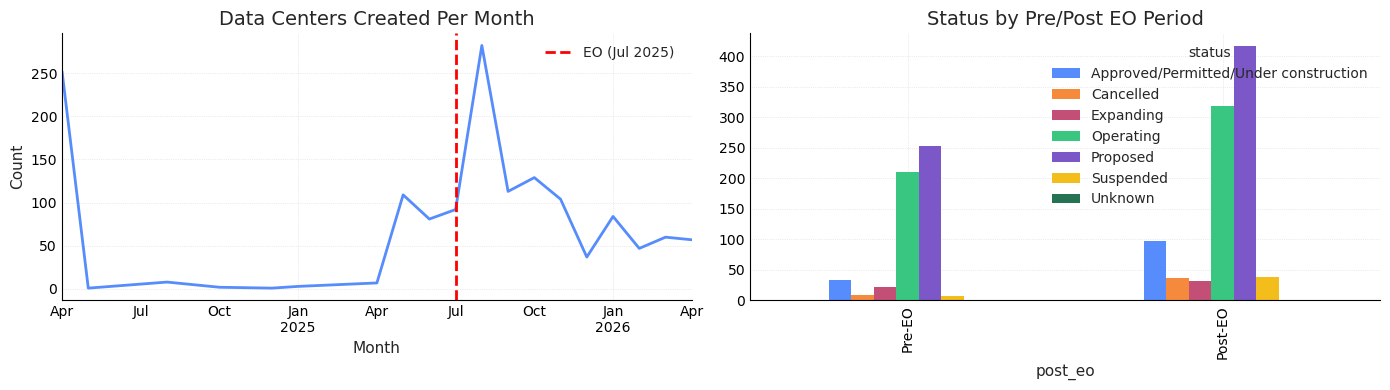

In [47]:
# plot DC creation over time
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
dc_df.groupby(
    dc_df['date_created'].dt.to_period('M')).size().plot(
    ax=axes[0], title="Data Centers Created Per Month", xlabel="Month", ylabel="Count"
)
axes[0].axvline(pd.Period('2025-07', 'M'), color='red', linestyle='--', label='EO (Jul 2025) ')
axes[0].legend()

dc_df.groupby(['post_eo', 'status']).size().unstack().plot(
    kind='bar', ax=axes[1], title="Status by Pre/Post EO Period"
)
axes[1].set_xticklabels(['Pre-EO', 'Post-EO'])
plt.tight_layout()
plt.show()

In [48]:
print("Days After Executive Order", dc_df.date_created.max() - EO_DATE)
print("Days before Executive Order", EO_DATE - dc_df.date_created.min())

Days After Executive Order 274 days 00:00:00
Days before Executive Order 469 days 00:00:00


## Section 3: Status Distribution & Executive Order

### Status values found:
In addition to 'Proposed' and 'Operating' categories, the data also contains:
- `Approved/Permitted/Under Construction` (131)
- `Expanding` (52)
- `Cancelled` (45)
- `Suspended` (45)
- `Unknown` (1)

### Decision — status_group:
It makes sense to collapse these into three groups that would capture active development, existing data centers.  Inactive isn't needed in the analysis but will kept for sensitivity analysis.
| status_group | Statuses included | N |
|---|---|---|
| In Pipeline | Proposed, Approved/Permitted/Under Construction, Expanding | 853 |
| Operating | Operating | 529 |
| Inactive | Cancelled, Suspended, Unknown | 91 |


### Executive Order cutoff — July 23, 2025:
We define a new variable `post_eo = True` for any DC with `date_created >= 2025-07-23`.

**Key finding:** The daily rate of proposed data center projects increased
~3.5x following the EO:
- Pre-EO: 0.54 proposals/day (253 proposals over 469 days)
- Post-EO: 1.52 proposals/day (417 proposals over 274 days)

**Important caveat:** There are a couple of large spikes spike in `date_created` April 2024 (101 entries) that might reflects a bulk data entry rather than real world activity.  This should be considered in light of using crowdsourced data.

In [49]:
print(f" Top 15 states: {dc_df['state'].value_counts().head(15)}")
print(f"Total states represented: {dc_df['state'].nunique()}")

 Top 15 states: state
VA    452
TX    177
GA    174
PA     98
OH     53
IN     37
NY     34
IL     31
AZ     29
NC     28
CA     25
MO     24
MI     23
OR     19
IA     19
Name: count, dtype: int64
Total states represented: 47


In [50]:
region_map = {
    'CT':'Northeast','ME':'Northeast','MA':'Northeast','NH':'Northeast',
    'RI':'Northeast','VT':'Northeast','NJ':'Northeast','NY':'Northeast','PA':'Northeast',
    'IL':'Midwest','IN':'Midwest','MI':'Midwest','OH':'Midwest','WI':'Midwest',
    'IA':'Midwest','KS':'Midwest','MN':'Midwest','MO':'Midwest','NE':'Midwest',
    'ND':'Midwest','SD':'Midwest',
    'DE':'South','FL':'South','GA':'South','MD':'South','NC':'South','SC':'South',
    'VA':'South','DC':'South','WV':'South','AL':'South','KY':'South','MS':'South',
    'TN':'South','AR':'South','LA':'South','OK':'South','TX':'South',
    'AZ':'West','CO':'West','ID':'West','MT':'West','NV':'West','NM':'West',
    'UT':'West','WY':'West','AK':'West','CA':'West','HI':'West','OR':'West','WA':'West'
}
dc_df['census_region'] = dc_df['state'].map(region_map)


In [51]:
print(f"by census region: {dc_df['census_region'].value_counts()}")
print(f"Status x Region: \n {pd.crosstab(dc_df['census_region'], dc_df['status'], margins=True)}")

by census region: census_region
South        937
Midwest      237
Northeast    155
West         144
Name: count, dtype: int64
Status x Region: 
 status         Approved/Permitted/Under construction  Cancelled  Expanding  \
census_region                                                                
Midwest                                           33         17          2   
Northeast                                          4          8          3   
South                                             74         17         42   
West                                              20          3          5   
All                                              131         45         52   

status         Operating  Proposed  Suspended  Unknown   All  
census_region                                                 
Midwest               48       117         20        0   237  
Northeast             66        68          5        1   155  
South                358       428         18        0  

In [52]:
missing_coords = dc_df[['lat', 'long']].isnull().any(axis=1).sum()
print(f"Rows missing lat/long: {missing_coords}")
print(f"location_confidence breakdown:\n {dc_df['location_confidence'].value_counts()}")

Rows missing lat/long: 0
location_confidence breakdown:
 location_confidence
High       1175
Medium      246
Low          46
Medium        3
High          2
high          1
Name: count, dtype: int64


## Section 4: Geographic Distribution

### Coverage:
- 47 states represented in dc_df
- Every state with a DC also has at least one Superfund site and there are no states with a data center that do not have a superfund site
- The US territories (AS, GU, PR, VI) appear in the superfund site but not in the dataset site.  This could be due to lack of data center activity in the territories or it could be due to the crowdsourced dataset.

### Regional skew:
The South accounts for 63% of all DCs (937 of 1,473), particularly
Virginia (452 DCs — Northern Virginia/Ashburn is the world's largest
data center market), Texas and Georgia.

### Decision — census_region:
States are mapped to four Census regions (Northeast, Midwest, South, West)
using a hardcoded lookup table. No states were unmapped.

In [53]:
# section 4
print(f"Shape: {sf_gdf.shape}")
print(f"Dtypes: {sf_gdf.dtypes}")

Shape: (2114, 33)
Dtypes: OBJECTID                          object
REGION_CODE                       object
EPA_PROGRAM                       object
EPA_ID                            object
SITE_NAME                         object
SITE_FEATURE_CLASS                object
SITE_FEATURE_TYPE                 object
SITE_FEATURE_NAME                 object
SITE_FEATURE_DESCRIPTION          object
NPL_STATUS_CODE                   object
FEDERAL_FACILITY_DETER_CODE       object
LAST_CHANGE_DATE                  object
ORIGINAL_CREATION_DATE            object
SITE_FEATURE_SOURCE               object
STREET_ADDR_TXT                   object
ADDR_COMMENT                      object
CITY_NAME                         object
COUNTY                            object
STATE_CODE                        object
ZIP_CODE                          object
SITE_CONTACT_NAME                 object
PRIMARY_TELEPHONE_NUM             object
SITE_CONTACT_EMAIL                object
URL_ALIAS_TXT                  

In [54]:
missing_sf = sf_gdf.isnull().sum()
missing_sf_pct = (missing_sf / len(sf_gdf) * 100).round(1)
missing_sf_df = pd.DataFrame({
    'missing_n': missing_sf,
    'missing_pct': missing_sf_pct
})
print(f"Missingness: {missing_sf_df[missing_sf_df.missing_n > 0].sort_values('missing_pct', ascending=False)}")


Missingness:           missing_n  missing_pct
GIS_AREA         54          2.6


In [55]:
# section 5
print(f"NLP_STATUS_CODE breakdown: {sf_gdf['NPL_STATUS_CODE'].value_counts()  }")
print(f"SITE_FEATURE_TYPE breakdown: {sf_gdf['SITE_FEATURE_TYPE'].value_counts()  }")
print(f"EPA REGION_CODE breakdown: {sf_gdf['REGION_CODE'].value_counts().sort_index()  }")

print(f"Total rows: {len(sf_gdf)}")
print(f"Unique EPA_IDs (sites): {sf_gdf['EPA_ID'].nunique()}")
print(f"Avg feature rows per site: {len(sf_gdf) / sf_gdf['EPA_ID'].nunique():.1f}")
print(f"GIS_AREA stats (acres): {sf_gdf['GIS_AREA'].describe().round(2)}")

print(f"\nGIS_AREA (acres) — non-null count: {sf_gdf['GIS_AREA'].notnull().sum()} of {len(sf_gdf)}")
print(f"\nGIS_AREA stats (acres):\n{sf_gdf['GIS_AREA'].describe().round(2)}")
print(f"\nValues that failed to parse (coerced to NaN): {sf_gdf['GIS_AREA'].isnull().sum()}")



NLP_STATUS_CODE breakdown: NPL_STATUS_CODE
F    1530
D     462
N      70
P      36
R      10
A       4
S       2
Name: count, dtype: int64
SITE_FEATURE_TYPE breakdown: SITE_FEATURE_TYPE
Comprehensive Site Area                       886
Current Ground Boundary                       554
Total Site Polygon/OU Aggregation             187
Site Boundary                                 172
Extent of Contamination                       155
OU Boundary Aggregation                        68
Other                                          53
<Null>                                         17
Contamination Boundary                          7
                                                6
Contamination Boundary (Groundwater)            5
Waste in Place                                  1
Comprehensive Site Boundary                     1
OU Boundary                                     1
Total Site Polygon/OU Boundary Aggregation      1
Name: count, dtype: int64
EPA REGION_CODE breakdown: REGION_CODE

## Section 5: Superfund Site Structure

### Deduplication:
The raw SF dataset has 2,114 rows but only [X] unique EPA_IDs. Multiple
rows per site reflect different boundary feature types. The dataset needed to be deduplicated to
one row per site using a priority ranking:

1. Comprehensive Site Area
2. Total Site Polygon/OU Aggregation
3. Current Ground Boundary
4. Site Boundary
5. OU Boundary Aggregation
6. Extent of Contamination
7. (other types)

Ties are broken by largest GIS_AREA.

### GIS_AREA unit inconsistency:
The raw `GIS_AREA_UNITS` column contains mixed units:
- `Acres` (1,367 rows) — used as-is
- `Square Miles` (382 rows) — converted: 1 sq mile = 640 acres
- `Miles` (138 rows) — the core challenge is that this is a linear measure that cannot be
  converted to area. These sites are flagged with `linear_site = 1`
  and their GIS_AREA_ACRES is set to null.


### NPL Status:
- Final NPL (`F`): 1,328 sites — primary analysis group
- Deleted (`D`): 459 sites — important secondary group given EPA policy
  of accelerating deletions to facilitate redevelopment
- Other (N, P, R, A, S): 115 sites — excluded from primary analysis


In [56]:
proposed = dc_df[dc_df['status'] == 'Proposed']
operating = dc_df[dc_df['status'] == 'Operating']
print(f"Proposed DC: {len(proposed)}")
print(f" - Post-EO: {proposed['post_eo'].sum()}")
print(f" - Pre-EO: {(~proposed['post_eo']).sum()}")

print(f"Operating DCs: {len(operating)}")
print(f" - Post-EO: {operating['post_eo'].sum()}")
print(f" - Pre-EO: {(~operating['post_eo']).sum()}")

print(f"DCs with valid coordinates: {dc_df[['lat', 'long']].notnull().all(axis=1).sum()}")
print(f"SF sites with geometry: {sf_gdf['geometry_wkt'].notnull().sum()}")
print(f"")

Proposed DC: 670
 - Post-EO: 417
 - Pre-EO: 253
Operating DCs: 529
 - Post-EO: 318
 - Pre-EO: 211
DCs with valid coordinates: 1473
SF sites with geometry: 2114



In [57]:
# Normalize by time window to get rate of proposals
pre_eo_days  = (EO_DATE - dc_df['date_created'].min()).days
post_eo_days = (dc_df['date_created'].max() - EO_DATE).days

pre_proposed  = (~dc_df['post_eo'] & (dc_df['status'] == 'Proposed')).sum()
post_proposed = (dc_df['post_eo']  & (dc_df['status'] == 'Proposed')).sum()

print(f"Pre-EO  proposal rate:  {pre_proposed  / pre_eo_days:.2f} per day")
print(f"Post-EO proposal rate:  {post_proposed / post_eo_days:.2f} per day")
print(f"Rate multiplier: {(post_proposed / post_eo_days) / (pre_proposed / pre_eo_days):.1f}x")

Pre-EO  proposal rate:  0.54 per day
Post-EO proposal rate:  1.52 per day
Rate multiplier: 2.8x


## Section 6: Preprocessing Steps

The following decisions were made based on this exploration and implemented
in `src/preprocess.py`:

| Decision | Rationale |
|---|---|
| Parse dates to datetime64 | Required for pre/post EO analysis |
| Coerce lat/long to float64 | Load as object, needed for geometry creation |
| Flag invalid coordinates | 1 DC had out-of-bounds coordinates |
| Normalize GIS_AREA to acres | Mixed units in raw data |
| Deduplicate SF to one row per EPA_ID | Multiple feature rows per site |
| Expand FEATURE_TYPE_PRIORITY | Raw data had more types than initially anticipated |
| Fix source_count NaN bug | .astype(str) converts NaN to "nan" |
| Save as .gpkg not .csv or .parquet | Preserves geometry and dtypes natively |
| Cast nullable Int64 to float64 | GeoPackage does not support pandas nullable integers |

## Next notebook:
`02 EDA Preprocessing and Feature Engineer.ipynb`